In [83]:
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.manifold import TSNE
import umap

In [84]:
data = load_diabetes(as_frame=True)


In [85]:
X = data.data
y = data.target


Text(0.5, 1.0, 'Feature Correlation Heatmap')

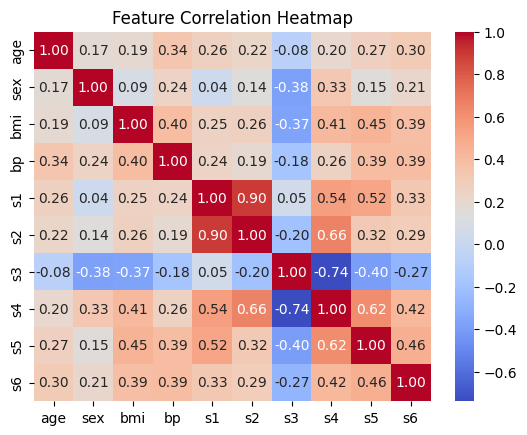

In [86]:
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')

<Axes: xlabel='s2', ylabel='s4'>

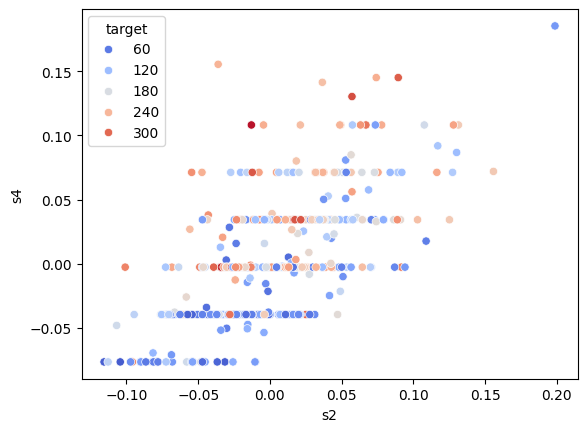

In [87]:
sns.scatterplot(x=X['s2'], y=X['s4'], hue=y, palette='coolwarm')

### PCA

In [88]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [89]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

## t-SNE

In [90]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

## UMAP

In [91]:
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

c:\documenten\LU2-AI-Prototype\AI-PoC\env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## Visualisatie

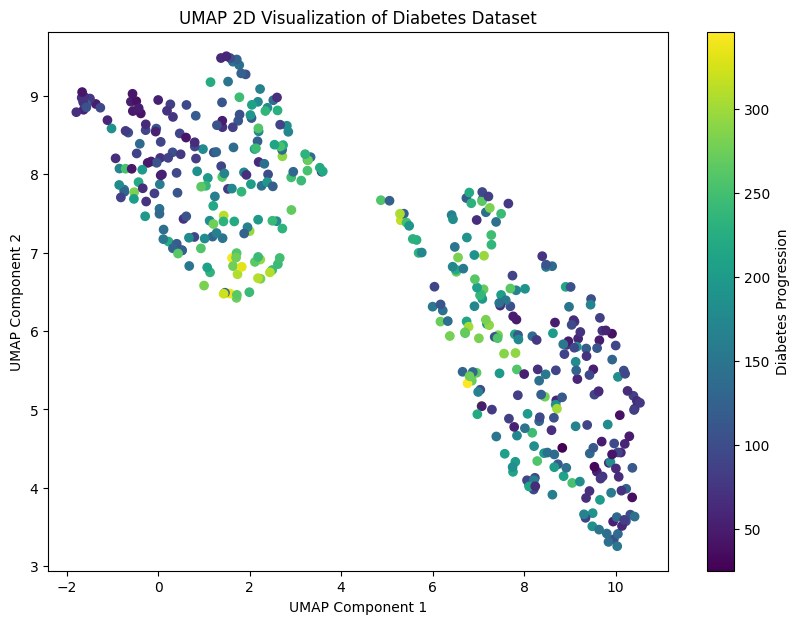

In [92]:
# Visualisatie van de UMAP-resultaten
plt.figure(figsize=(10, 7))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='viridis')
plt.colorbar(label='Diabetes Progression')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.title('UMAP 2D Visualization of Diabetes Dataset')
plt.show()

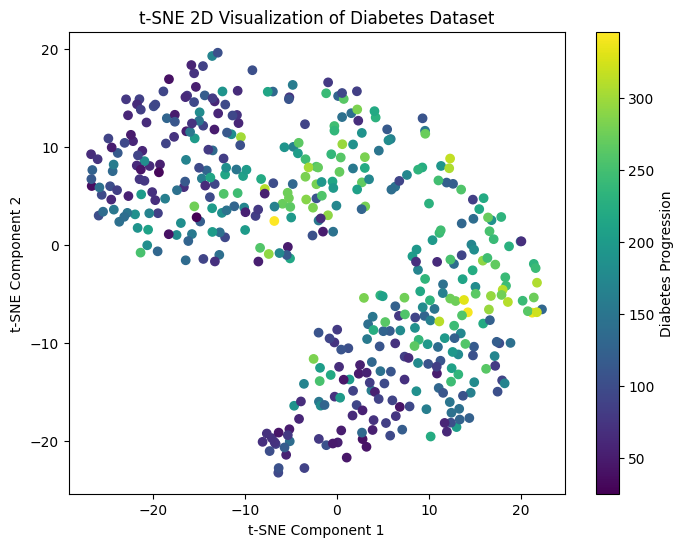

In [93]:
## Visualisatie van de t-SNE-resultaten
plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis')
plt.colorbar(label='Diabetes Progression')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE 2D Visualization of Diabetes Dataset')
plt.show()

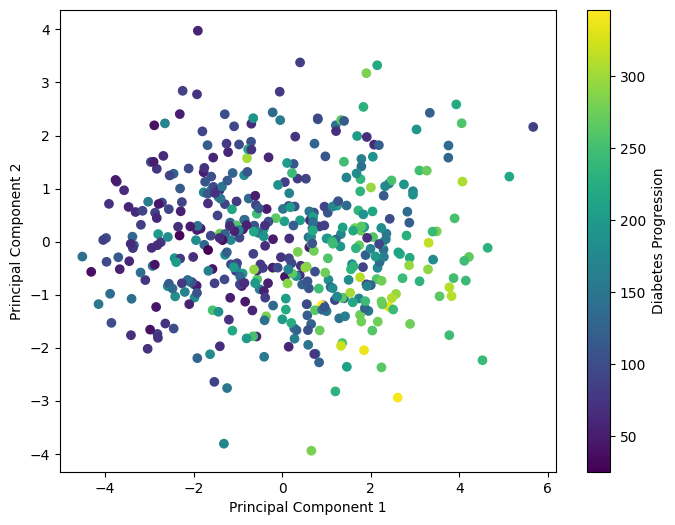

In [94]:
# Visualisatie van de PCA-resultaten
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.colorbar(label='Diabetes Progression')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

####

# Beantwoord in een Markdown-cel of kort tekstblok:
### 1. Hoe verschillen de visualisaties van elkaar?

##### - Bij PCA lijden de punten willekeurig verspreid je ziet geen duidelijke cluster. De kleur laat wel een geleidelijke overgang zien, dus er is wel een patroon, maat het is niet goed zichtbaar.
##### - Bij UMAP en t-SNE zie je wel duidelijke groepen waarin punten dicht bij elkaar liggen.

### 2. Welke techniek laat de clusters of patronen het duidelijkst zien?

##### - De UMAP t-SNE laten de clusters of patronen duidelijk zien. De groepen zijn duidelijk te zien. maar UMAP laat het beste zien.

### 3. Hoe interpreteer jij het verschil tussen PCA en t-SNE / UMAP?

##### - PCA is een lineaire techniek. Het probeert de richtingen van grootste variantie in de data te vinden. Daardoor kan je met PCA alleen rechte verbanden zien.
##### - UMAP en t-SNE zijn niet lineaire technieken. Deze technieken kijken naar de nabijheid tussen de punten en proberen die structuur te behouden bij het verkleinen van de dimensies.
#####   Daardoor zijn de patronen beter zichtbaar.

### 4. Welke techniek zou jij kiezen voor de eindopdracht, en waarom

##### - Als ik de Visualisaties zie, dan zou ik voor UMAP gaan. Het laat duidelijke clusters zien.